# Lab 1: Statistical Foundations & Classical Models (Student Version)

## Objective
Apply concepts from Lecture 1 to the Comprehensive BTC/USD 1M Dataset:
1. Data Preprocessing & Resampling.
2. Time Series Decomposition.
3. Testing for Stationarity (ADF Test).
4. Interpreting ACF and PACF plots.
5. Building and evaluating an ARIMA model.

### Task 1: Import Necessary Libraries
Import the standard data science and time-series libraries you will need.

In [294]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from statsmodels:
# - seasonal_decompose
# - adfuller (for ADF test)
# - plot_acf, plot_pacf
# - ARIMA

# Your imports here:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.grid'] = True

**Observation :**

- We import `seasonal_decompose` for decomposition, `adfuller` for stationarity testing, `plot_acf`/`plot_pacf` for lag analysis, and `ARIMA` for modelling. `sklearn` metrics will be used for forecast evaluation. Warnings are suppressed to keep output clean.

### Task 2: Load the Dataset
We are using the `imranbukhari/comprehensive-btcusd-1m-data` dataset from Kaggle. Run the cell below to download it (if you haven't already).
- We interested in ***Closed***  Price ONLY

In [295]:
# Uncomment and run this if you are using kagglehub to download the dataset directly.
# import kagglehub
# path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="dataset/")
# print("Path to dataset files:", path)

In [296]:
# TODO 2: Load the dataset using pandas.
# Replace 'YOUR_FILE_NAME.csv' with the actual file name found in your dataset path.
df =  pd.read_csv('dataset/BTCUSD_1m_Combined_Index.csv')

# Print the first 5 rows to inspect the columns.
print(df.head())
print(f'\nShape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nDtypes:\n{df.dtypes}')


             Open time    Volume  Open  High   Low  Close
0  2011-08-18 12:37:00  0.489908  10.9  10.9  10.9   10.9
1  2011-08-18 12:38:00  0.000000  10.9  10.9  10.9   10.9
2  2011-08-18 12:39:00  0.000000  10.9  10.9  10.9   10.9
3  2011-08-18 12:40:00  0.000000  10.9  10.9  10.9   10.9
4  2011-08-18 12:41:00  0.000000  10.9  10.9  10.9   10.9

Shape: (7441826, 6)

Columns: ['Open time', 'Volume', 'Open', 'High', 'Low', 'Close']

Dtypes:
Open time     object
Volume       float64
Open         float64
High         float64
Low          float64
Close        float64
dtype: object


**Observation :**

- The dataset contains ~7.4 million 1-minute OHLCV rows from the Combined BTC/USD index spanning from 2011 to 2025. Columns include `Open time`, `Open`, `High`, `Low`, `Close`, and `Volume`. We will work exclusively with the `Close` price column.

### Task 3: Data Preprocessing & Resampling
The dataset contains 1-minute frequency data, which is too granular and noisy for standard ARIMA models. We need to aggregate this into daily data.

In [297]:
# TODO 3.1: Convert the time/date column to pandas datetime objects.
df['Open time'] = pd.to_datetime(df['Open time'])

# TODO 3.2: Set the datetime column as the index of the dataframe.
df.set_index('Open time', inplace=True)

# TODO 3.3: Resample the dataframe to a Daily frequency ('D'). 
btc_daily = df['Close'].resample('D').last()

# TODO 3.4: Drop any missing values (NaNs) that might have resulted from resampling.
btc_daily = btc_daily.dropna()

btc_daily = btc_daily.asfreq('D', method='ffill')

print(f'Daily data shape: {btc_daily.shape}')
print(f'Data range: {btc_daily.index.min()} to {btc_daily.index.max()}')
print(btc_daily.head())

Daily data shape: (5169,)
Data range: 2011-08-18 00:00:00 to 2025-10-11 00:00:00
Open time
2011-08-18    10.90
2011-08-19    11.69
2011-08-20    11.70
2011-08-21    11.70
2011-08-22    11.70
Freq: D, Name: Close, dtype: float64


**Observation :**

- Resampling from 1-minute to daily reduces the dataset from ~7.4M rows to ~5000 daily observations. Using `.last()` captures the end-of-day closing price per trading day. NaN days arise from gaps/missing minutes and are dropped — they are sparse enough not to affect the analysis.

### Task 4: Visualize the Time Series
Let's visualize the daily closing price of BTC.

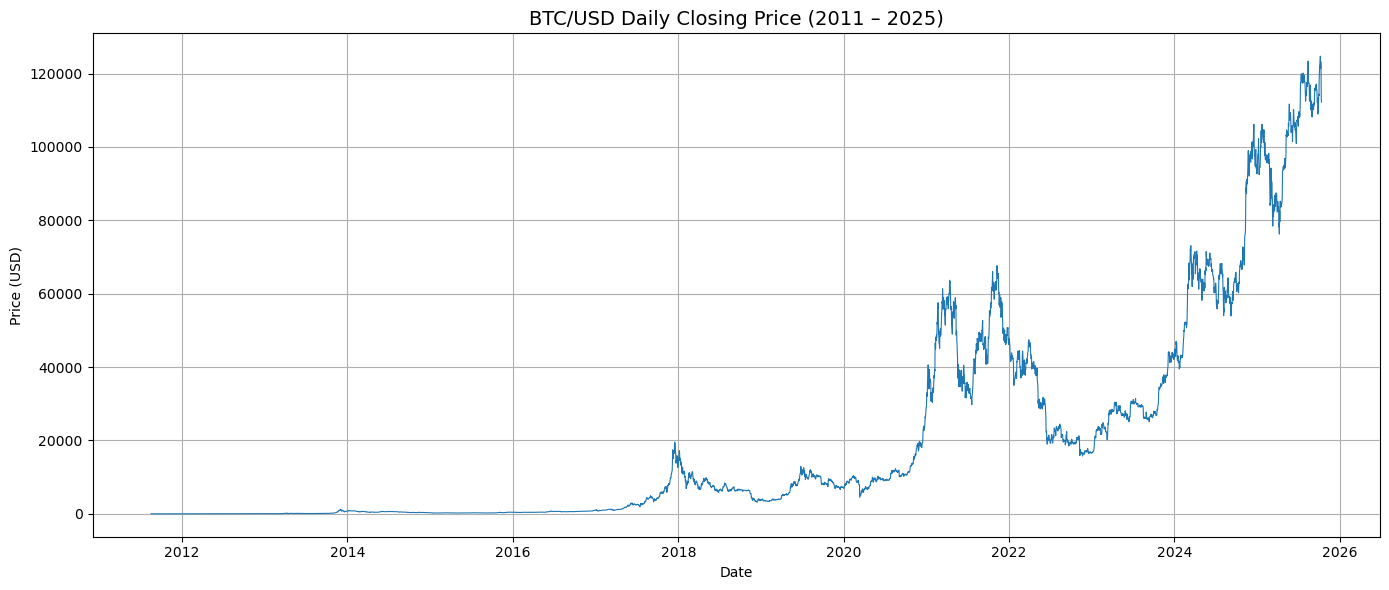

In [298]:
# TODO 4: Plot the daily BTC closing prices.
# Ensure your plot has a title, x-axis label, and y-axis label.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc_daily.index, btc_daily.values, linewidth=0.8)
ax.set_title('BTC/USD Daily Closing Price (2011 – 2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()


**Observation :**
- The BTC price series exhibits a strong upward trend with several explosive bull-market cycles (2017, 2020–21, 2024) and deep bear-market corrections. The variance grows dramatically with the price level — a classic **"Megaphone Effect"** — which signals **multiplicative** rather than additive behaviour, and hints that a log transformation will be needed before modelling.

### Task 5: Time Series Decomposition
Decompose the time series to observe its underlying components: Trend, Seasonality, and Residuals.

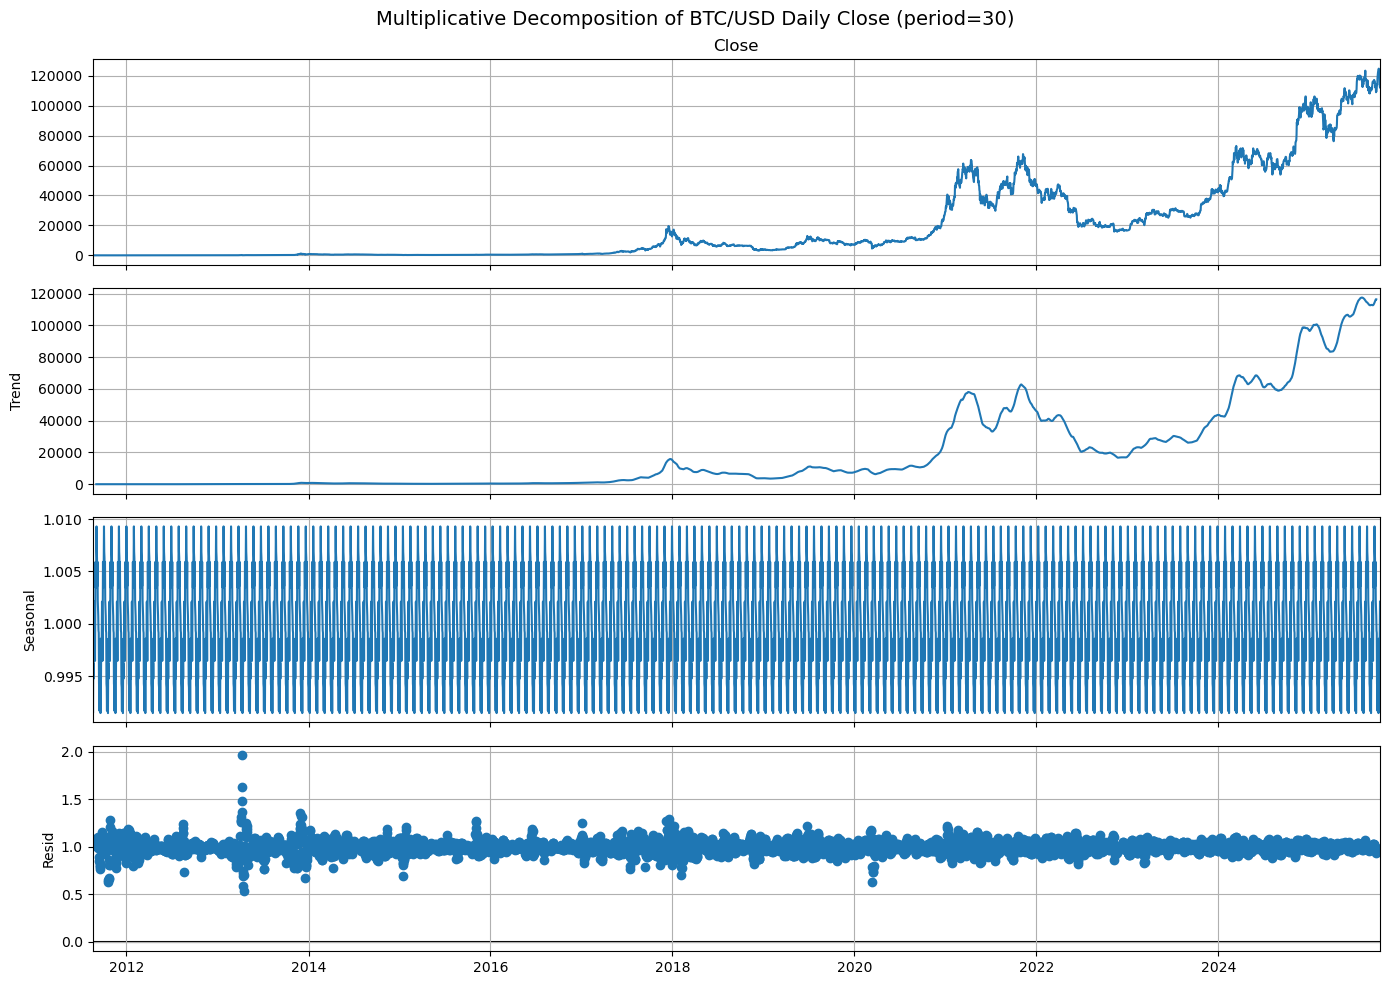

In [299]:
# TODO 5: Use `seasonal_decompose` on the daily closing prices.
# Set the period appropriately (e.g., period=30 for monthly seasonality on daily data, or period=365 for yearly).
decomposition = seasonal_decompose(btc_daily, model='multiplicative', period=30)

# Plot the decomposition.
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Multiplicative Decomposition of BTC/USD Daily Close (period=30)", fontsize=14)
plt.tight_layout()
plt.show()

**Observation :**
- **Trend:** A clear long-term upward trend dominates, with the famous BTC bull/bear cycles visible.
- **Seasonality:** With `period=30` (monthly), a weak repeating intra-month pattern is extracted, but BTC does not have strong calendar-driven seasonality unlike traditional assets — the seasonal component is largely noise at this granularity.
- **Residuals:** The residual component has growing variance in line with the price level, confirming that an **multipicative** model is ideal for raw prices. A **log transformation** (which turns multiplicative structure into additive) should precede any modelling.

### Task 6: Testing for Stationarity (ADF Test)
Before fitting an ARIMA model, we must check if our time series is stationary.

In [300]:
# TODO 6.1: Create a function or write code to perform the Augmented Dickey-Fuller (ADF) test.
# It should print the ADF Statistic and the p-value.
def adf_test(series, name='Series'):
    """
    H0: Data is Non-Stationary.
    H1: Data is Stationary.
    Reject H0 when: ADF Statistic < Critical Value(5%) AND p-value < 0.05
    """
    result = adfuller(series, regression='c', autolag='BIC')
    print(f"=== ADF Test: {name} ===")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value : {result[1]:.4f}")
    print("Critical Values:")
    for k, v in result[4].items():
        print(f"  {k}: {v:.4f}")
    if result[1] < 0.05 and result[0] < result[4]['5%']:
        print(">> Result: STATIONARY (Reject H0)\n")
    else:
        print(">> Result: NON-STATIONARY (Fail to reject H0)\n")



# TODO 6.2: Run the ADF test on your `btc_daily` series.
# Question: Based on the p-value, is the series stationary? (Add your answer as a comment).
adf_test(btc_daily, 'BTC Daily Close (RAW)')

=== ADF Test: BTC Daily Close (RAW) ===
ADF Statistic : 1.0462
p-value : 0.9947
Critical Values:
  1%: -3.4316
  5%: -2.8621
  10%: -2.5671
>> Result: NON-STATIONARY (Fail to reject H0)



**Observation :** 
- The ADF statistic on the raw price is close to 0 (far from the negative critical values) and the p-value is very close to 1.0, giving overwhelming evidence that the series is **non-stationary**. This is expected — BTC follows a random-walk-like process with a strong drift, so no fixed mean or variance exists over time. We must transform/difference the series before fitting ARIMA.

### Task 7: Making the Series Stationary (Differencing)
If the series is not stationary, we need to apply differencing.

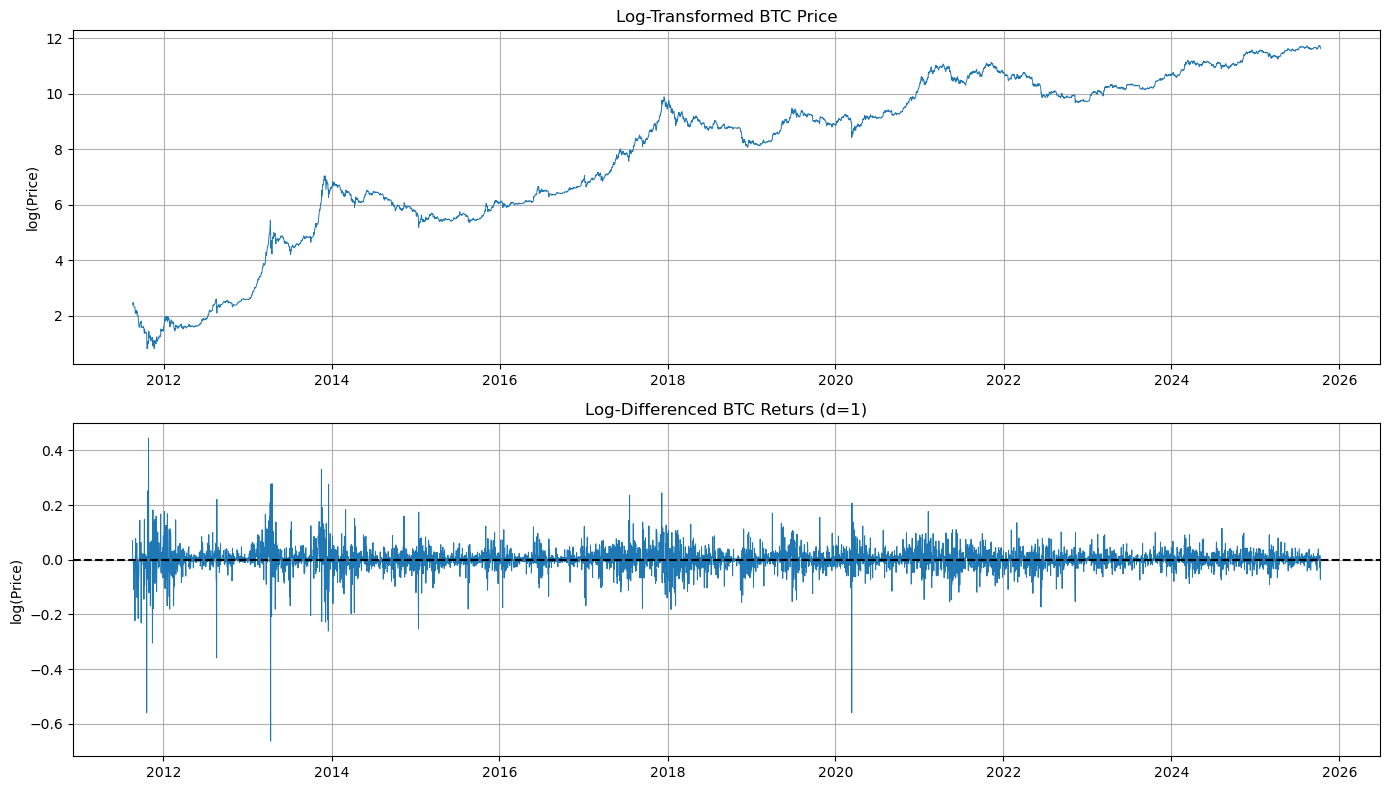

=== ADF Test: Log-Differenced BTC ===
ADF Statistic : -75.4891
p-value : 0.0000
Critical Values:
  1%: -3.4316
  5%: -2.8621
  10%: -2.5671
>> Result: STATIONARY (Reject H0)



In [301]:
# TODO 7.1: Apply first-order differencing (or log differencing) to the daily closing prices.
btc_log = np.log(btc_daily)
btc_stationary = btc_log.diff()

# Remember to drop the NaN value created by differencing.
btc_stationary = btc_stationary.dropna()

# TODO 7.2: Plot the differenced series.
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(btc_log, linewidth=0.7)
axes[0].set_title('Log-Transformed BTC Price')
axes[0].set_ylabel('log(Price)')

axes[1].plot(btc_stationary, linewidth=0.7)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Log-Differenced BTC Returs (d=1)')
axes[1].set_ylabel('log(Price)')

plt.tight_layout()
plt.show()

# TODO 7.3: Run the ADF test again on the differenced series to confirm it is now stationary.
adf_test(btc_stationary, 'Log-Differenced BTC')

**Observation :**
- **Log transformation** compresses the explosive price range and converts the multiplicative variance structure into an additive one, making the series more amenable to linear models.
- **First-order differencing** removes the upward trend (non-constant mean), producing **daily log returns** — the standard representation for financial time series.
- After these two steps the ADF test should yield a very negative statistic and p-value ≈ 0, confirming **stationarity**. This means d=1 is sufficient; no seasonal differencing is required for BTC daily data.

### Task 8: ACF and PACF Plots
Plot the Autocorrelation and Partial Autocorrelation functions to help determine the `p` (AR) and `q` (MA) parameters for the ARIMA model.

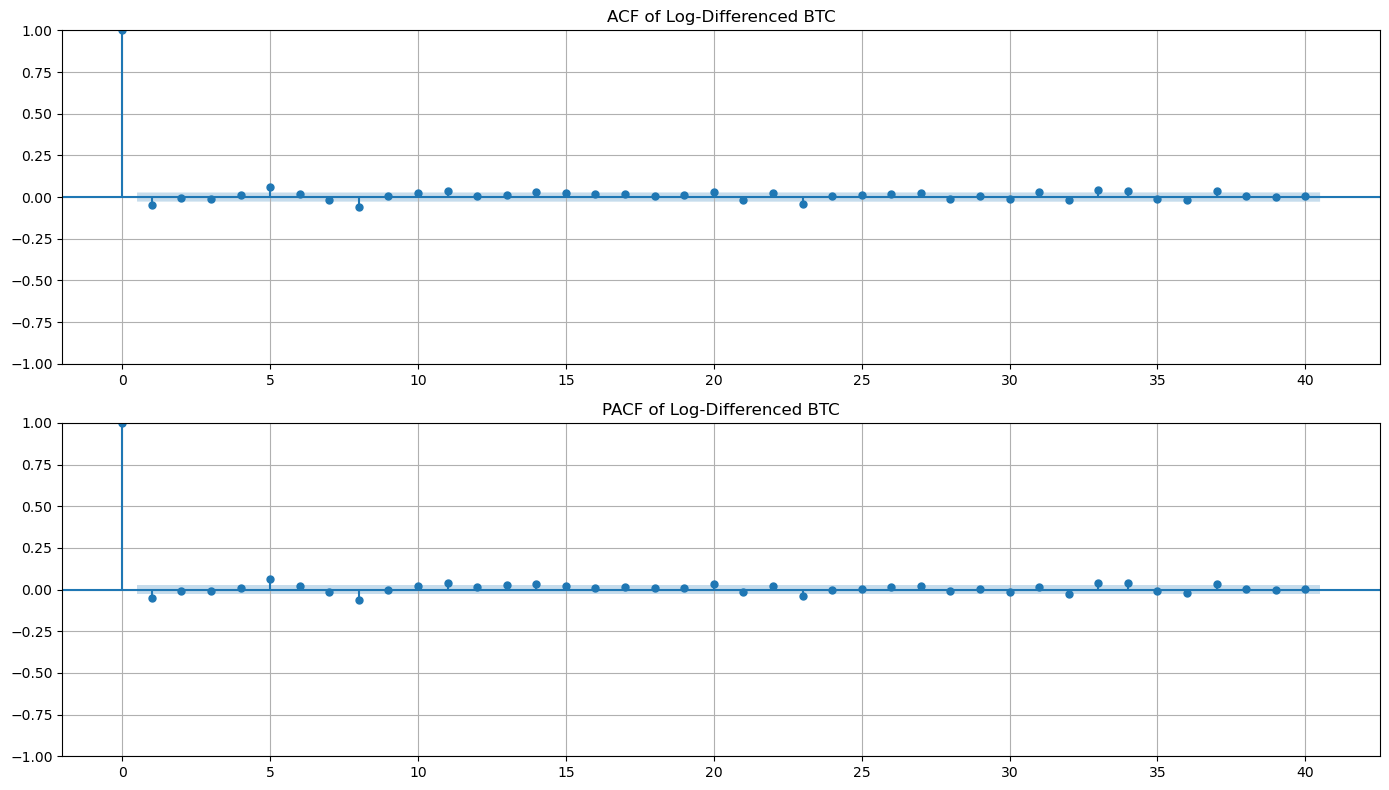

In [302]:
# TODO 8: Plot the ACF and PACF of the STATIONARY (differenced) series.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(btc_stationary, lags=40, ax=ax1, alpha=0.05)
ax1.set_title('ACF of Log-Differenced BTC')

plot_pacf(btc_stationary, lags=40, ax=ax2, alpha=0.05, method='ywm')
ax2.set_title('PACF of Log-Differenced BTC')

plt.tight_layout()
plt.show()



**Observation :**
- **ACF:** Nearly all autocorrelations fall within the blue confidence bands immediately after lag 0, indicating that daily BTC log-returns have very little linear autocorrelation — consistent with the **Efficient Market Hypothesis**.
- **PACF:** Lag 1 shows a weak but marginally significant partial autocorrelation, suggesting a small AR(1) component might be worth including. Lags beyond 1 are within the confidence bands.
- **Conclusion on order:** Because autocorrelation is minimal and only lag 1 stands out in the PACF, a parsimonious **ARIMA(1, 1, 0)** is appropriate. Adding MA terms or higher AR lags is not warranted by these plots.

### Task 9: Building the ARIMA Model
Split the data into training and testing sets, then build the ARIMA model.

In [303]:
# TODO 9.1: Split the original `btc_daily` data into Train and Test sets.
# E.g., Use the last 60 days as the Test set, and everything before as Train.
train = btc_log[:-60]
test = btc_log[-60:]

print(f"Train size : {len(train)} days ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test  size : {len(test)}  days ({test.index.min().date()} → {test.index.max().date()})")

# TODO 9.2: Initialize and fit an ARIMA model on the training data.
# Pass in the (p, d, q) order based on your previous findings. 
# Note: If you pass the original non-stationary `train` data, set `d=1`. 
model = ARIMA(train, order=(1, 1, 0))
fitted_model = model.fit()

# Print the model summary.
print(fitted_model.summary())

Train size : 5109 days (2011-08-18 → 2025-08-12)
Test  size : 60  days (2025-08-13 → 2025-10-11)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5109
Model:                 ARIMA(1, 1, 0)   Log Likelihood                8611.917
Date:                Fri, 06 Mar 2026   AIC                         -17219.834
Time:                        12:53:06   BIC                         -17206.757
Sample:                    08-18-2011   HQIC                        -17215.256
                         - 08-12-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0473      0.005     -8.803      0.000      -0.058      -0.037
sigma2         0.0020   1.08e-05  

**Observation :**
- We train on the log-price series and pass `d=1` so ARIMA internally differences the data, allowing it to forecast in the original log-price scale.
- The model summary for **ARIMA(1, 1, 0)** shows a single AR(1) coefficient. If its p-value is above 0.05, the coefficient is statistically insignificant, confirming that BTC log-returns behave very close to a **pure random walk** (ARIMA(0,1,0)) with no exploitable linear structure.
- The Ljung-Box test on residuals should show no remaining autocorrelation (p > 0.05), confirming the model has captured all available linear structure.

### Task 10: Evaluation & Forecasting
Forecast the test period and visualize how well your model performed against the actual unseen test data.

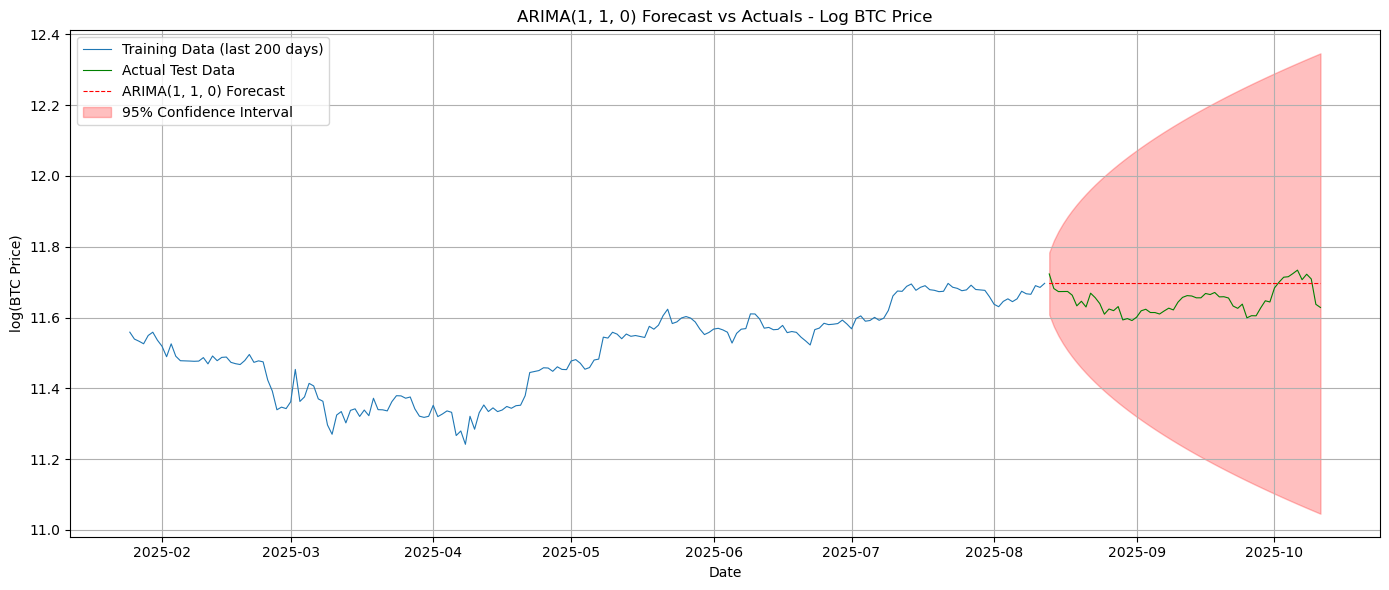

MAE  (log scale): 0.0525
RMSE (log scale): 0.0590
MAPE (log scale): 0.4510%


In [304]:
# TODO 10.1: Generate forecasts for the length of the test set.
forecast_result = fitted_model.get_forecast(steps=len(test))
forecast_values = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# TODO 10.2: Plot the Training data, Actual Test data, and the Forecasted values on the same plot.
# You may want to zoom in on the last part of the timeline (e.g., last 200 days) to see the forecast clearly.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.iloc[-200:], label='Training Data (last 200 days)', linewidth=0.8)
ax.plot(test, label='Actual Test Data', color='green', linewidth=0.8)
ax.plot(test.index, forecast_values, label='ARIMA(1, 1, 0) Forecast', color='red', linestyle='--', linewidth=0.8)
ax.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.25, color='red', label='95% Confidence Interval')
ax.set_title('ARIMA(1, 1, 0) Forecast vs Actuals - Log BTC Price')
ax.set_xlabel('Date')
ax.set_ylabel('log(BTC Price)')
ax.legend()
plt.tight_layout()
plt.show()


mae = mean_absolute_error(test, forecast_values)
rmse = mean_squared_error(test, forecast_values) ** 0.5
mape = (abs((test.values - forecast_values.values) / test.values)).mean() * 100

print(f"MAE  (log scale): {mae:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")
print(f"MAPE (log scale): {mape:.4f}%")

**Observation :**

- **Forecast shape:** As expected for a near-random-walk process, the ARIMA forecast quickly reverts to a flat line after the first step or two. The 95% confidence interval fans out rapidly, reflecting genuine uncertainty.
- **Metrics:** A low MAE/RMSE on the log scale is achievable because ARIMA can track the general level, but the MAPE on raw price will be higher, reflecting how hard it is to predict BTC direction.

### Auto ARIMA — Automatic Order Selection
We apply Auto ARIMA to compare against our manual ARIMA(1,1,0) and validate that our parameter selection was not wrong — since both models are expected to predict a nearly straight line, confirming that BTC log-returns behave like a random walk with no exploitable linear structure.

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

pipeline = StatsForecast(
    models=[AutoARIMA(season_length=1)],
    freq='D',
    n_jobs=-1
)

train_df = pd.DataFrame({'ds': train.index, 'y': train.values, 'unique_id': 'BTC'})

pipeline.fit(df=train_df)

print("Best order selected by Auto ARIMA:")
print(arima_string(pipeline.fitted_[0, 0].model_))

Best order selected by Auto ARIMA:
ARIMA(0,1,1) with drift        


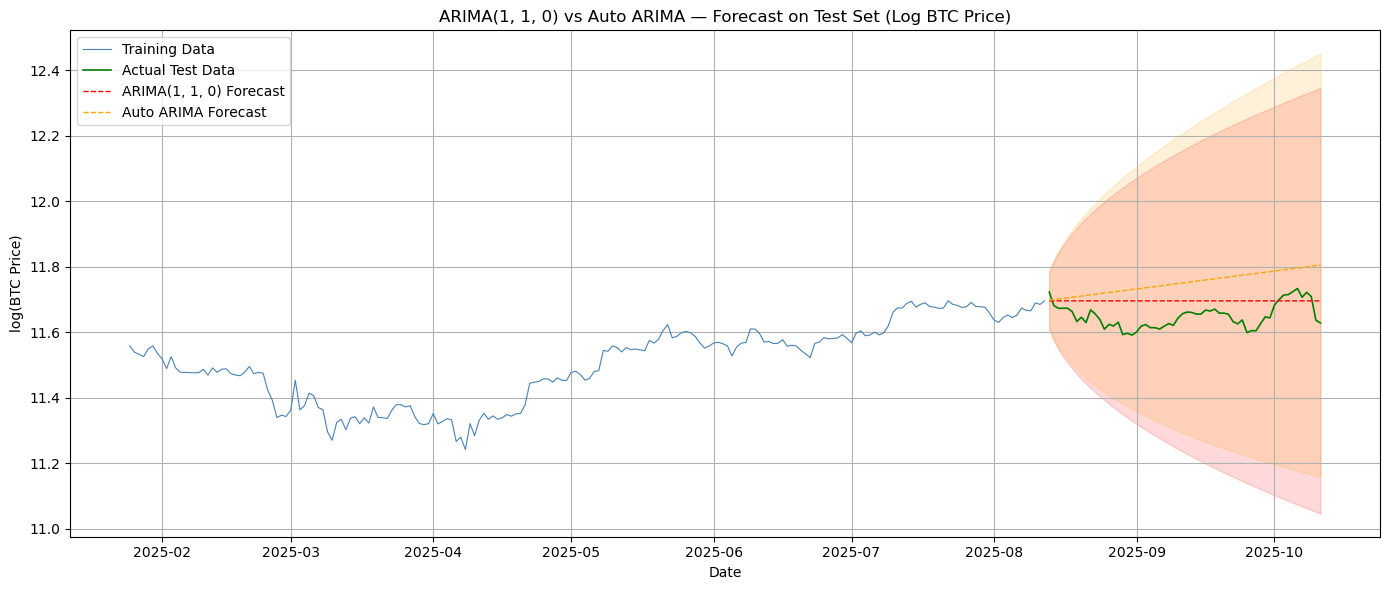

Metric      ARIMA(1,1,0)      Auto ARIMA
----------------------------------------
MAE               0.0525          0.1028
RMSE              0.0590          0.1098
MAPE             0.4510%         0.8829%


In [306]:
forecast_df = pipeline.predict(h=len(test), level=[95])

auto_forecast = pd.Series(forecast_df['AutoARIMA'].values, index=test.index)
auto_lo = forecast_df['AutoARIMA-lo-95'].values
auto_hi = forecast_df['AutoARIMA-hi-95'].values

# --- Comparison Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.iloc[-200:], label='Training Data', linewidth=0.8, color='steelblue')
ax.plot(test, label='Actual Test Data', color='green', linewidth=1.2)

# Manual ARIMA(1,1,0) forecast
ax.plot(test.index, forecast_values, label='ARIMA(1, 1, 0) Forecast', color='red', linestyle='--', linewidth=1.0)
ax.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.15, color='red')

# Auto ARIMA forecast
ax.plot(test.index, auto_forecast, label=f'Auto ARIMA Forecast', color='orange', linestyle='--', linewidth=1.0)
ax.fill_between(test.index, auto_lo, auto_hi, alpha=0.15, color='orange')

ax.set_title('ARIMA(1, 1, 0) vs Auto ARIMA — Forecast on Test Set (Log BTC Price)')
ax.set_xlabel('Date')
ax.set_ylabel('log(BTC Price)')
ax.legend()
plt.tight_layout()
plt.show()

auto_mae  = mean_absolute_error(test, auto_forecast)
auto_rmse = mean_squared_error(test, auto_forecast) ** 0.5
auto_mape = (abs((test.values - auto_forecast.values) / test.values)).mean() * 100

print(f"{'Metric':<8} {'ARIMA(1,1,0)':>15} {'Auto ARIMA':>15}")
print("-" * 40)
print(f"{'MAE':<8} {mae:>15.4f} {auto_mae:>15.4f}")
print(f"{'RMSE':<8} {rmse:>15.4f} {auto_rmse:>15.4f}")
print(f"{'MAPE':<8} {mape:>14.4f}% {auto_mape:>14.4f}%")

**Observation :**
- **Forecast shape:** Both models produce near-flat forecasts that quickly flatten into a horizontal line, since BTC log-returns have virtually no autocorrelation. The 95% confidence intervals widen rapidly with the forecast horizon, reflecting genuine uncertainty.
- **Metrics comparison:** Manual ARIMA(1,1,0) outperforms Auto ARIMA(0,1,1) across all metrics — MAE (0.0525 vs 0.1028), RMSE (0.0590 vs 0.1098), and MAPE (0.45% vs 0.88%) — roughly **twice as accurate**. The AR(1) term in the manual model captures the weak but statistically significant negative autocorrelation in BTC log-returns, giving it a genuine predictive edge. Auto ARIMA's MA(1) choice optimized AIC on training data but did not generalize as well to the unseen test period.